# ICS 604: APPLIED DATA SCIENCE

## Random Number Generation in Python and Common Plot Types

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

## Random Number Generation

The data we generate throughout this course will be **pseudorandom**, meaning it is produced by deterministic algorithms designed to generate sequences that appear random. These algorithms start from an initial value called a **seed** and then use a mathematical procedure to generate a sequence of numbers based on that seed. Because the process is deterministic, using the same seed will always produce the same sequence of “random” values.

While pseudorandom number generators are not suitable for security or cryptographic purposes, they are ideal — and even recommended — for data science. Their reproducibility is a major advantage, as it allows experiments and simulations to be repeated and verified under identical conditions.

In Python, basic random functionality is provided by the standard `random` library, which supports common operations such as sampling, shuffling, and selecting random elements. For more advanced use cases, especially those involving probability distributions, NumPy offers a richer set of tools. In addition to replicating the functionality of `random`, NumPy provides more flexible and efficient sampling strategies, including many non-uniform probability distributions commonly used in data analysis and modeling.

### (Pseudo)-Random Number Generation and Seeds

In pseudorandom number generation, both the *seed* and the *generation strategy* fully determine the sequence of numbers that is produced. Once a seed is fixed, the algorithm will always generate the same sequence of values, even though those values appear random. This property is what enables reproducibility in simulations and data analysis.

For example, suppose the chosen strategy is a uniform distribution over the range `[0, 100]`. If we initialize the random number generator with a specific seed and repeatedly draw numbers from this range, the resulting sequence will be identical every time the program is run with that same seed. Changing the seed, or changing the distribution strategy, will produce a different sequence of values. This interplay between the seed and the sampling strategy is central to how pseudorandom number generators work in practice.

<center><img src="https://www.dropbox.com/scl/fi/nexjy5is542vzivqwzf7a/rng.png?rlkey=gjkngywle4zb2npugmw5cln1a&st=4i7n3yem&dl=1"></center>

In [2]:
import random

random.seed(2)
random.randint(0, 100)   # random integer in [0, 100]

7

In [3]:
# Random sampling after setting a seed
random.seed(2)
rand_numbers = []
for i in range(10):
    rand_numbers.append(random.randint(0, 100))
print(rand_numbers)

[7, 11, 10, 46, 21, 94, 85, 39, 32, 77]


In [4]:
# Random sampling without setting a seed
rand_numbers = []
for i in range(20):
    rand_numbers.append(random.randint(0, 100))
print(rand_numbers)

[27, 77, 4, 74, 87, 20, 55, 81, 50, 92, 65, 47, 69, 56, 64, 34, 4, 3, 46, 59]


In [5]:
# Random sampling after resetting a seed
random.seed(2)
rand_numbers = []
for i in range(10):
    rand_numbers.append(random.randint(0, 100))
print(rand_numbers)

[7, 11, 10, 46, 21, 94, 85, 39, 32, 77]


### Useful `random` Functions

* `random.seed(s)`:  Set the seed of the pseudo-random number generator to `s`.
* `random.ranint(l, u)` : Generate a random integer uniformly distributed in the inclusive range [l, u].
* `random.random()` : Generate a random number uniformly distributed in the range [0, 1).
* `random.choice(items)`: Select a single random element from the sequence `items`.
* `random.choices(items, k=n)`: Select `n` random elements from `items` **with replacement**, meaning the same element may be chosen multiple times.
* `random.sample(items, k=n)`: Sample `n` random elements from `items` **without replacement**, where `n <= len(items)`.
* `random.shuffle(items)`: Randomly permutes the elements of `items` **in place**, modifying the original sequence.

In [6]:
random.seed(42)
random.choice(["CS", "Math", "Eng", "Econ"])

'CS'

In [7]:
random.seed(42)
random.choices(["CS", "Math", "Eng", "Econ"], k=4)

['Eng', 'CS', 'Math', 'CS']

In [8]:
random.seed(42)
random.sample(["CS", "Math", "Eng", "Econ"], k=4)

['CS', 'Econ', 'Math', 'Eng']

In [9]:
random.seed(42)
random.choices(["CS", "Math", "Eng", "Econ"], k=5)

['Eng', 'CS', 'Math', 'CS', 'Eng']

In [10]:
random.seed(42)
random.sample(["CS", "Math", "Eng", "Econ"], k=5)

ValueError: Sample larger than population or is negative

In [11]:
items = [1, 2, 3, 4, 5, 6]
random.shuffle(items)
print(items)

[4, 2, 3, 5, 1, 6]


### Equivalent `NumPy` Random Functions

* `np.random.seed(s)`:  Set the seed of NumPy’s pseudorandom number generator to `s`.
* `np.random.randint(low, high, k)` : Generate `k` random integers uniformly distributed in the range [low, high).
  * If `high` is `None` (default), then results are from `[0, low)`.
  * `k` specifies the output shape and can be an integer or a tuple of integers.
* `np.random.rand(d0, d1, ..., dn)`: Generate an array of shape (d0, d1, ..., dn) with values drawn uniformly from the interval [0, 1).
* `np.random.choice(items, size=k, replace=True)`: Randomly select `k` elements from `items`.
   * Sampling is **with replacement** by default (`replace=True`).
   * Setting `replace=False` is equivalent to sampling without replacement.
   * This single function replaces the need for both `random.choices()` and `random.sample()`. 
* `np.random.shuffle(items)`: Randomly permutes the elements of `items` **in place**, modifying the original array or list.
* `np.random.random(size)` and `np.random.random_sample(size)` (or`np.random.sample(size)`): Generate random values uniformly distributed in [0,1).
   * Equivalent in purpose to `np.random.rand(...)`, but uses a `size` argument instead of separate shape parameters.
   * Note: `np.random.sample()` is not the same as Python’s `random.sample()`.
      * NumPy’s version generates uniform floats, whereas Python’s version samples elements without replacement from a sequence.

In [12]:
np.random.randint(0, 10, 10)

array([9, 8, 0, 7, 3, 2, 0, 7, 1, 8], dtype=int32)

In [13]:
np.random.randint(5, None, 10)

array([3, 0, 2, 0, 2, 2, 4, 4, 4, 2], dtype=int32)

In [14]:
np.random.randint(0, 10, (2, 5))

array([[8, 0, 5, 9, 5],
       [0, 8, 2, 3, 2]], dtype=int32)

In [15]:
np.random.rand(5)

array([0.51200738, 0.91974307, 0.15185909, 0.95452719, 0.78348153])

In [16]:
np.random.rand(2, 4)

array([[0.01689614, 0.95493204, 0.58407199, 0.65731195],
       [0.14448022, 0.9466456 , 0.42010803, 0.50983149]])

In [17]:
# rand, sample and random_sample have the same default behavior
np.random.seed(42)
print(np.random.random_sample(10))
print("-------------------------")
np.random.seed(42)
print(np.random.sample(10))   # alias of random_sample
print("-------------------------")
np.random.seed(42)
print(np.random.random(10))
print("-------------------------")
np.random.seed(42)
print(np.random.rand(10))

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]
-------------------------
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]
-------------------------
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]
-------------------------
[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258]


In [18]:
np.random.seed(42)
print(np.random.random_sample((2, 3)))
print("-------------------------")
np.random.seed(42)
print(np.random.sample((2, 3)))
print("-------------------------")
np.random.seed(42)
print(np.random.random((2, 3)))
print("-------------------------")
np.random.seed(42)
print(np.random.rand(2, 3))

[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]
-------------------------
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]
-------------------------
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]
-------------------------
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]


In [19]:
np.random.seed(42)
print(np.random.random_sample((2, 3, 2)))
print("-------------------------")
np.random.seed(42)
print(np.random.sample((2, 3, 2)))
print("-------------------------")
np.random.seed(42)
print(np.random.random((2, 3, 2)))
print("-------------------------")
np.random.seed(42)
print(np.random.rand(2, 3, 2))

[[[0.37454012 0.95071431]
  [0.73199394 0.59865848]
  [0.15601864 0.15599452]]

 [[0.05808361 0.86617615]
  [0.60111501 0.70807258]
  [0.02058449 0.96990985]]]
-------------------------
[[[0.37454012 0.95071431]
  [0.73199394 0.59865848]
  [0.15601864 0.15599452]]

 [[0.05808361 0.86617615]
  [0.60111501 0.70807258]
  [0.02058449 0.96990985]]]
-------------------------
[[[0.37454012 0.95071431]
  [0.73199394 0.59865848]
  [0.15601864 0.15599452]]

 [[0.05808361 0.86617615]
  [0.60111501 0.70807258]
  [0.02058449 0.96990985]]]
-------------------------
[[[0.37454012 0.95071431]
  [0.73199394 0.59865848]
  [0.15601864 0.15599452]]

 [[0.05808361 0.86617615]
  [0.60111501 0.70807258]
  [0.02058449 0.96990985]]]


In [20]:
items = [1, 2, 3, 4, 5, 6]
np.random.shuffle(items)
items

[5, 3, 1, 6, 2, 4]

## Basic Plot Types
### Line Plot

A line plot displays data points connected by a line. It is commonly used when the x-axis represents continuous data, such as time-series measurements, or when treating the x-axis as continuous is reasonable. Line plots are especially useful for showing trends or changes over time.

Multiple lines can be combined in the same plot for comparison. By default, lines are solid, but different styles, colors, or markers can be applied to distinguish between them, making it easier to compare multiple datasets in a single visualization.

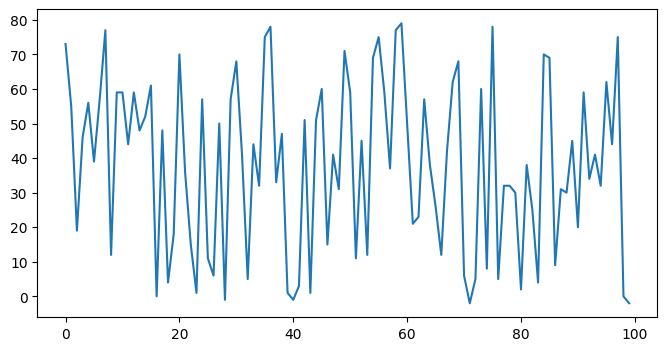

In [21]:
plt.figure(figsize=(8, 4))

time = np.arange(0, 100)
profit = np.random.randint(-2, 80, 100)
plt.plot(time, profit)
plt.show()

### Scatter Plot

A scatter plot visualizes the relationship between two variables by plotting individual data points as symbols, such as dots or circles, across the x- and y-axes. Each mark represents a single data instance with its corresponding values on both axes.

Scatter plots are typically used when data represent multiple entities. They can also incorporate additional dimensions: a third variable can be encoded using symbol shapes for categorical data or symbol size and color (hue) for continuous data. While scatter plots can represent more than three dimensions, adding too many is usually not recommended, as it can reduce clarity and interpretability.

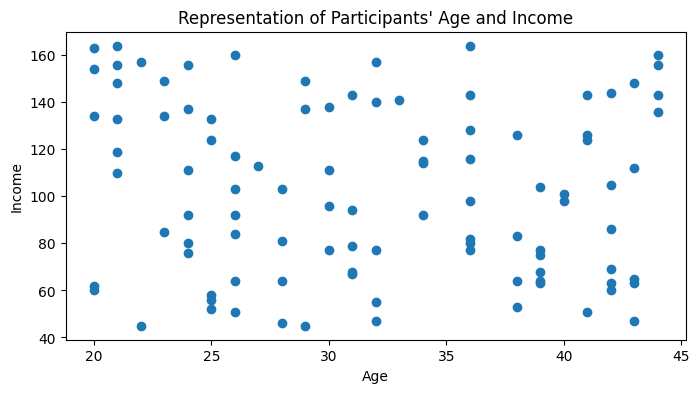

In [22]:
age = np.random.randint(20, 45, 100)
income = np.random.randint(45, 165, 100)

plt.figure(figsize=(8, 4))
plt.scatter(age, income)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Representation of Participants' Age and Income")
plt.show()

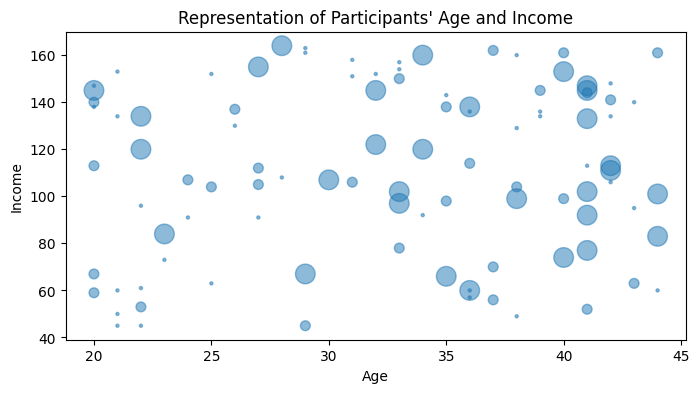

In [23]:
age = np.random.randint(20, 45, 100)
income = np.random.randint(45, 165, 100)
credit_score = np.random.choice([5, 50, 200], 100)

plt.figure(figsize=(8, 4))
plt.scatter(age, income, s=credit_score, alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Representation of Participants' Age and Income")
plt.show()

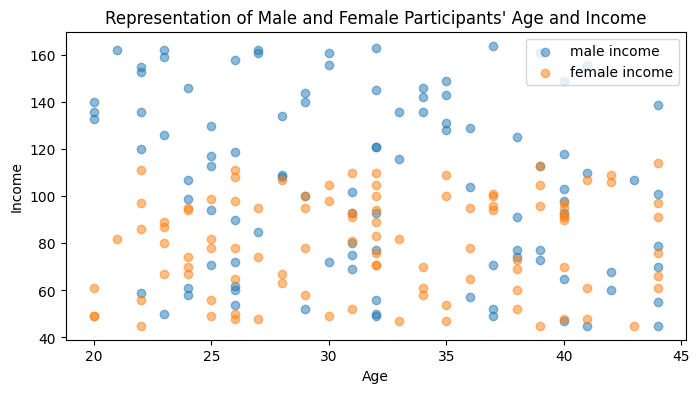

In [24]:
plt.figure(figsize=(8, 4))

age = np.random.randint(20, 45, 100)
income_male = np.random.randint(45, 165, 100)
income_female = np.random.randint(45, 115, 100)

plt.scatter(age, income_male, alpha=0.5, label="male income")
plt.scatter(age, income_female, alpha=0.5, label="female income")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Representation of Male and Female Participants' Age and Income")
plt.show()

### Bar Plot

A bar plot is used to visualize the relationship between a categorical variable and a numeric variable. Each unique category is represented by a bar, and the length or height of the bar corresponds to the numerical value associated with that category. For example, a bar plot can show the number of students in different departments such as ICS, Engineering, Physics, Economics, and Math.

Bar plots can also incorporate additional factors within each category. For instance, the number of students in each department can be further split by gender, with bars displayed side by side or stacked. This allows comparison across multiple subgroups while maintaining a clear visual representation of the data.

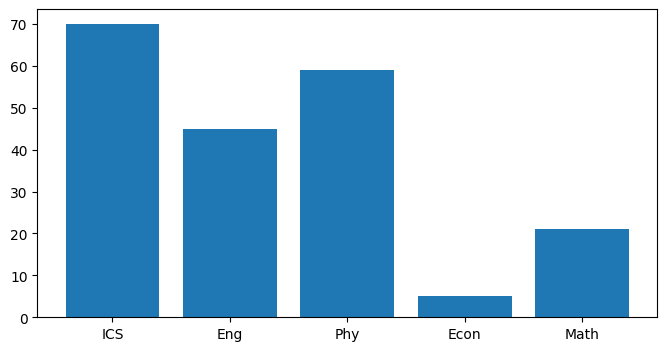

In [25]:
discipline = ["ICS", "Eng", "Phy", "Econ", "Math"]
nb_students = [70, 45, 59, 5, 21]

plt.figure(figsize=(8,4))
plt.bar(discipline, nb_students)
plt.show()

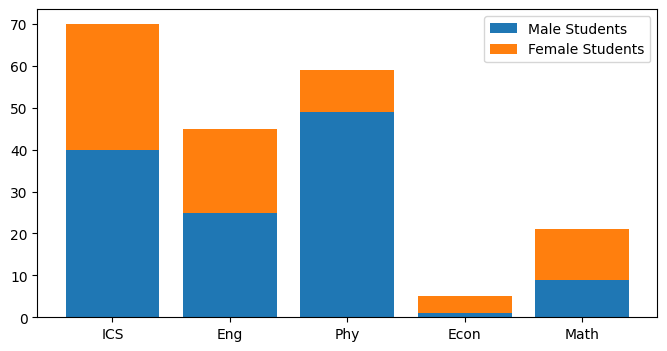

In [26]:
discipline = ["ICS", "Eng", "Phy", "Econ", "Math"]
nb_male_students = [40, 25, 49, 1, 9]
nb_female_students = [30, 20, 10, 4, 12]

x_values = np.arange(len(discipline))

plt.figure(figsize=(8,4))
plt.bar(x_values, nb_male_students, label="Male Students")
plt.bar(x_values, nb_female_students, bottom=nb_male_students, label="Female Students")
plt.xticks(x_values, discipline)
plt.legend()
plt.show()

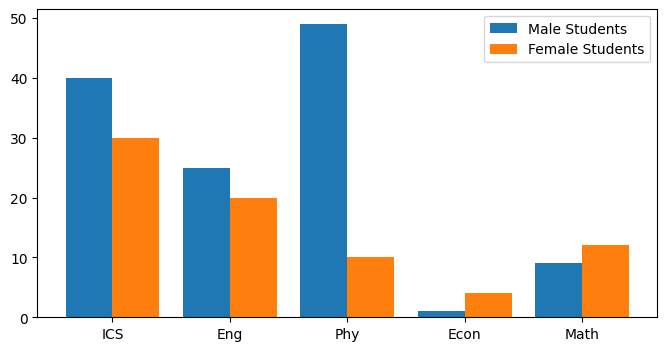

In [27]:
discipline = ["ICS", "Eng", "Phy", "Econ", "Math"]
nb_male_students = [40, 25, 49, 1, 9]
nb_female_students = [30, 20, 10, 4, 12]

x_values = np.arange(len(discipline))
bar_width = 0.4

plt.figure(figsize=(8,4))
plt.bar(x_values - bar_width/2, nb_male_students, width=bar_width, label="Male Students")
plt.bar(x_values + bar_width/2, nb_female_students, width=bar_width, label="Female Students")
plt.xticks(x_values, discipline)
plt.legend()
plt.show()

,nb_mail_students,nb_femail_students
ICS,40,30
Eng,25,20
Phy,49,10
Econ,1,4
Math,9,12


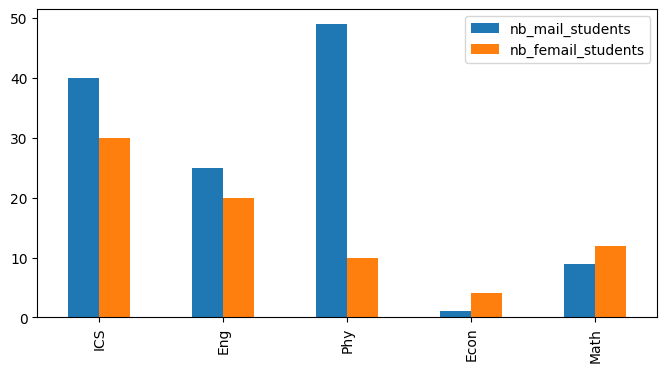

In [28]:
discipline = ["ICS", "Eng", "Phy", "Econ", "Math"]

df = pd.DataFrame({"nb_mail_students": [40, 25, 49, 1, 9],
                   "nb_femail_students": [30, 20, 10, 4, 12]},
                  index=discipline)
display(df)

df.plot.bar(figsize=(8, 4));

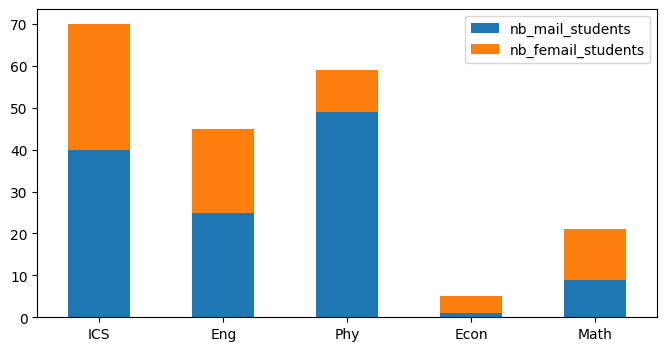

In [29]:
df.plot.bar(stacked=True, figsize=(8, 4), rot=0);

### Histogram

A histogram is a graphical representation that organizes a dataset into contiguous intervals, called *bins*, and displays the frequency of observations within each bin. By grouping data in this way, a histogram provides a clear picture of the underlying distribution of the variable, allowing one to observe patterns such as skewness, modality, and concentration of values. The height of each bar in a histogram corresponds to the number of data points that fall within that bin, which can also be interpreted as an empirical approximation of the probability of observing a value in that range.

Histograms are particularly useful when analyzing unidimensional data, as they reveal how values are distributed across a continuum. The choice of bin size plays a critical role in shaping the visualization: too few bins may obscure important details, while too many can create excessive noise. Modern plotting libraries, such as Matplotlib or NumPy, provide methods to automatically determine an appropriate number of bins based on the dataset. Overall, histograms are a foundational tool in exploratory data analysis, helping to summarize large datasets, detect outliers, and guide further statistical modeling.

(array([103., 106., 107., 111.,  84., 105.,  97.,  84.,  97., 106.]),
 array([ 0. ,  9.9, 19.8, 29.7, 39.6, 49.5, 59.4, 69.3, 79.2, 89.1, 99. ]),
 <BarContainer object of 10 artists>)

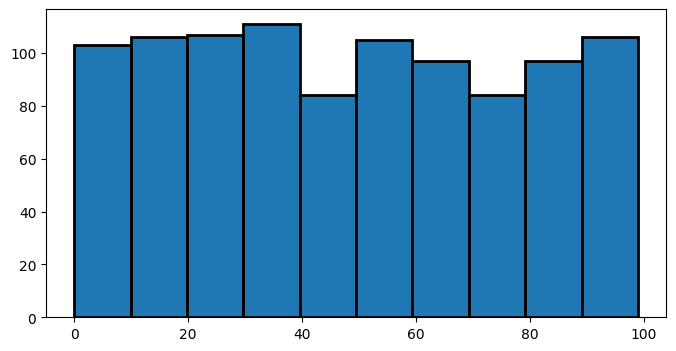

In [30]:
data = np.random.randint(0, 100, 1000)

plt.figure(figsize=(8, 4))
plt.hist(data, edgecolor='black', linewidth=2)

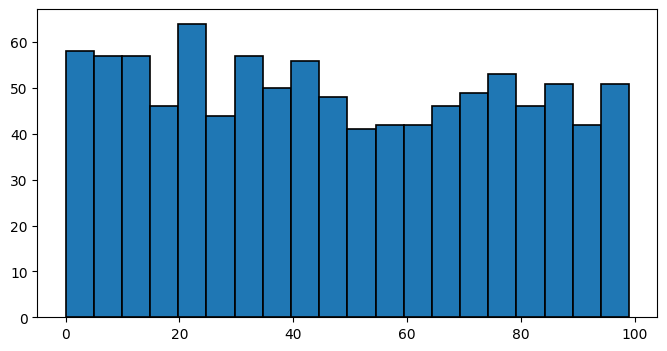

In [31]:
data = np.random.randint(0, 100, 1000)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=20, edgecolor='black', linewidth=1.2)
plt.show()